# 03 Baseline Model - TF-IDF + Logistic Regression

This notebook builds the first baseline model,We treat the task as **binary text classification**: classifying each health-related text as either reliable (`1`) or misinformation / unreliable (`0`).


## Why this model first?

We start with **TF-IDF + Logistic Regression** because it is fast, strong as a research baseline, easy to explain, and works very well in Jupyter Notebook. It lets us establish a clean benchmark before moving to heavier transformer models like **BioBERT** or **DistilBERT** later.


In [1]:
from pathlib import Path
import json

import joblib
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline


In [2]:
PROJECT_ROOT = Path(r'C:\Users\ribam\Desktop\Reseach\Dataset')
DATA_PATH = PROJECT_ROOT / 'dataset' / 'processed' / 'fakehealth_healthfact_binary_clean.csv'
MODEL_DIR = PROJECT_ROOT / 'model'
OUTPUT_DIR = PROJECT_ROOT / 'output'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH


WindowsPath('C:/Users/ribam/Desktop/Reseach/Dataset/dataset/processed/fakehealth_healthfact_binary_clean.csv')

In [3]:
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
df[['dataset', 'split', 'label_binary', 'text']].head(3)


Shape: (12231, 14)


,dataset,split,label_binary,text
0,fakehealth,release,0,"MADISON, Wis. -- More than 700 million adults ..."
1,fakehealth,release,1,"Wilmington, DE, December 17, 2018 - The CRISPR..."
2,fakehealth,release,0,About 3 million people in the US are diagnosed...


## Split Strategy

Because `healthfact` already has `train/dev/test` splits while `FakeHealth` does not, we use a **hybrid split strategy**:

- keep `healthfact` original `train`, `dev`, and `test`
- split `FakeHealth` randomly into `train`, `dev`, and `test` with stratification by label
- combine those partitions into final train/dev/test sets


In [4]:
healthfact_df = df[df['dataset'] == 'healthfact'].copy()
fakehealth_df = df[df['dataset'] == 'fakehealth'].copy()

fake_train, fake_temp = train_test_split(
    fakehealth_df,
    test_size=0.30,
    stratify=fakehealth_df['label'],
    random_state=42
)
fake_dev, fake_test = train_test_split(
    fake_temp,
    test_size=0.50,
    stratify=fake_temp['label'],
    random_state=42
)

train_df = pd.concat([healthfact_df[healthfact_df['split'] == 'train'], fake_train], ignore_index=True)
dev_df = pd.concat([healthfact_df[healthfact_df['split'] == 'dev'], fake_dev], ignore_index=True)
test_df = pd.concat([healthfact_df[healthfact_df['split'] == 'test'], fake_test], ignore_index=True)

print('Train shape:', train_df.shape)
print('Dev shape:', dev_df.shape)
print('Test shape:', test_df.shape)


Train shape: (9588, 14)
Dev shape: (1332, 14)
Test shape: (1311, 14)


In [5]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=30000, ngram_range=(1, 2), min_df=2, stop_words='english')),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42))
])

pipeline.fit(train_df['text'], train_df['label'])
print('Baseline model trained.')


Baseline model trained.


In [6]:
def evaluate_split(model, frame, split_name):
    y_true = frame['label']
    y_pred = model.predict(frame['text'])
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
    metrics = {
        'split': split_name,
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'precision': float(precision),
        'recall': float(recall),
        'f1': float(f1),
    }
    return metrics, y_pred

dev_metrics, dev_pred = evaluate_split(pipeline, dev_df, 'dev')
test_metrics, test_pred = evaluate_split(pipeline, test_df, 'test')

dev_metrics, test_metrics


({'split': 'dev',
  'accuracy': 0.683933933933934,
  'precision': 0.7755960729312763,
  'recall': 0.6793611793611793,
  'f1': 0.7242960052390308},
 {'split': 'test',
  'accuracy': 0.6872616323417239,
  'precision': 0.7713458755426917,
  'recall': 0.6789808917197452,
  'f1': 0.7222222222222222})

In [7]:
print('Dev classification report')
print(classification_report(dev_df['label'], dev_pred, digits=4))
print('Test classification report')
print(classification_report(test_df['label'], test_pred, digits=4))


Dev classification report
              precision    recall  f1-score   support

           0     0.5784    0.6911    0.6297       518
           1     0.7756    0.6794    0.7243       814

    accuracy                         0.6839      1332
   macro avg     0.6770    0.6852    0.6770      1332
weighted avg     0.6989    0.6839    0.6875      1332

Test classification report
              precision    recall  f1-score   support

           0     0.5935    0.6996    0.6422       526
           1     0.7713    0.6790    0.7222       785

    accuracy                         0.6873      1311
   macro avg     0.6824    0.6893    0.6822      1311
weighted avg     0.7000    0.6873    0.6901      1311



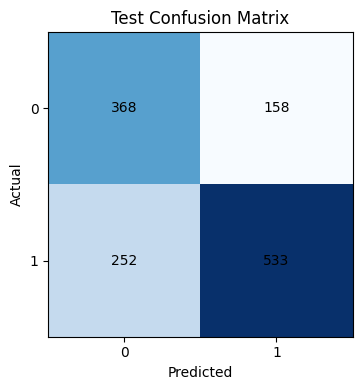

In [8]:
import os
MPLCONFIGDIR = OUTPUT_DIR / '.matplotlib'
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ['MPLCONFIGDIR'] = str(MPLCONFIGDIR)
import matplotlib.pyplot as plt
cm = confusion_matrix(test_df['label'], test_pred)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_title('Test Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black')
plt.tight_layout()
plt.show()


In [9]:
model_path = MODEL_DIR / 'tfidf_logreg_fakehealth_healthfact.joblib'
metrics_path = OUTPUT_DIR / 'tfidf_logreg_metrics.json'
predictions_path = OUTPUT_DIR / 'tfidf_logreg_test_predictions.csv'

joblib.dump(pipeline, model_path)

metrics = {
    'model': 'TF-IDF + Logistic Regression',
    'train_rows': int(len(train_df)),
    'dev_rows': int(len(dev_df)),
    'test_rows': int(len(test_df)),
    'dev_metrics': dev_metrics,
    'test_metrics': test_metrics,
}
metrics_path.write_text(json.dumps(metrics, indent=2), encoding='utf-8')

test_output = test_df[['dataset', 'split', 'record_id', 'text', 'label']].copy()
test_output['prediction'] = test_pred
test_output.to_csv(predictions_path, index=False)

print('Saved model to:', model_path)
print('Saved metrics to:', metrics_path)
print('Saved predictions to:', predictions_path)
metrics


Saved model to: C:\Users\ribam\Desktop\Reseach\Dataset\model\tfidf_logreg_fakehealth_healthfact.joblib
Saved metrics to: C:\Users\ribam\Desktop\Reseach\Dataset\output\tfidf_logreg_metrics.json
Saved predictions to: C:\Users\ribam\Desktop\Reseach\Dataset\output\tfidf_logreg_test_predictions.csv


{'model': 'TF-IDF + Logistic Regression',
 'train_rows': 9588,
 'dev_rows': 1332,
 'test_rows': 1311,
 'dev_metrics': {'split': 'dev',
  'accuracy': 0.683933933933934,
  'precision': 0.7755960729312763,
  'recall': 0.6793611793611793,
  'f1': 0.7242960052390308},
 'test_metrics': {'split': 'test',
  'accuracy': 0.6872616323417239,
  'precision': 0.7713458755426917,
  'recall': 0.6789808917197452,
  'f1': 0.7222222222222222}}

## Next Step

Once this baseline is stable, the next model to compare would be a transformer-based model such as **DistilBERT** or **BioBERT**.
